In [115]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
np.random.seed(42)
tf.random.set_seed(42)

In [116]:
def generate_synthetic_data(num_samples, img_shape):
    h, w, c = img_shape
    images = []

    for i in range(num_samples):
        img = np.zeros((h, w, c), dtype=np.float32)
        pattern = i % 5  # 5 different pattern types for variety

        xx, yy = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))

        if pattern == 0:
            # Radial gradient
            cx, cy = np.random.rand(), np.random.rand()
            r = np.sqrt((xx - cx)**2 + (yy - cy)**2)
            for ch in range(c):
                img[:,:,ch] = np.clip(1 - r * np.random.uniform(1, 3), 0, 1)

        elif pattern == 1:
            # Sine wave interference
            freq1, freq2 = np.random.uniform(2, 8), np.random.uniform(2, 8)
            for ch in range(c):
                img[:,:,ch] = 0.5 + 0.5 * np.sin(freq1 * xx * np.pi + np.random.rand()) \
                                        * np.cos(freq2 * yy * np.pi + np.random.rand())

        elif pattern == 2:
            # Diagonal stripes with colour variation
            angle = np.random.uniform(0, np.pi)
            stripe = np.sin((xx * np.cos(angle) + yy * np.sin(angle)) \
                            * np.random.uniform(5, 15) * np.pi)
            for ch in range(c):
                img[:,:,ch] = np.clip(0.5 + 0.5 * stripe * np.random.rand(), 0, 1)

        elif pattern == 3:
            # Concentric rings
            cx, cy = np.random.rand(), np.random.rand()
            r = np.sqrt((xx - cx)**2 + (yy - cy)**2)
            rings = np.sin(r * np.random.uniform(10, 25) * np.pi)
            for ch in range(c):
                img[:,:,ch] = np.clip(0.5 + 0.4 * rings * np.random.rand(), 0, 1)

        else:
            # Colour wash — smooth random colour field
            for ch in range(c):
                base = np.random.rand()
                img[:,:,ch] = np.clip(base + 0.3 * (xx * np.random.rand()
                                                    + yy * np.random.rand()), 0, 1)

        # Normalize to [-1, 1]
        img = img * 2 - 1
        images.append(img)

    return np.array(images, dtype=np.float32)

synthetic_data = generate_synthetic_data(5000, (28, 28, 3))
print("Data shape:", synthetic_data.shape)

Data shape: (5000, 28, 28, 3)


In [117]:
latent_dim = 100

def build_generator(latent_dim):
    model = tf.keras.Sequential([
        # Smaller projection — 7x7x64 instead of 7x7x256
        layers.Dense(7 * 7 * 64, use_bias=False, input_dim=latent_dim),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((7, 7, 64)),

        # Upsample to 14x14
        layers.Conv2DTranspose(32, kernel_size=4, strides=2,
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # Upsample to 28x28
        layers.Conv2DTranspose(16, kernel_size=4, strides=2,
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # Final output — (28, 28, 3) with tanh
        layers.Conv2DTranspose(3, kernel_size=4, strides=1,
                               padding='same', use_bias=False,
                               activation='tanh')
    ])
    return model

In [118]:
def build_discriminator(img_shape):
    model = tf.keras.Sequential([
        layers.Conv2D(64, kernel_size=4, strides=2,
                      padding='same', input_shape=img_shape),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, kernel_size=4, strides=2,
                      padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [119]:
def build_gan(generator, discriminator):
    discriminator.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    discriminator.trainable = False

    gan_input  = layers.Input(shape=(latent_dim,))
    img        = generator(gan_input)
    gan_output = discriminator(img)

    gan = tf.keras.Model(gan_input, gan_output)
    gan.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
        loss='binary_crossentropy'
    )

    return gan

0/300 [D loss: 0.7102, acc.: 17.19%] [G loss: 0.6528]
10/300 [D loss: 0.6316, acc.: 0.00%] [G loss: 0.3098]
20/300 [D loss: 0.5844, acc.: 0.00%] [G loss: 0.3502]
30/300 [D loss: 0.5875, acc.: 0.00%] [G loss: 0.1917]
40/300 [D loss: 0.5898, acc.: 0.00%] [G loss: 0.3056]
50/300 [D loss: 0.6427, acc.: 0.00%] [G loss: 0.2794]
60/300 [D loss: 0.6130, acc.: 3.12%] [G loss: 0.4544]
70/300 [D loss: 0.6264, acc.: 15.62%] [G loss: 0.6476]
80/300 [D loss: 0.5566, acc.: 50.00%] [G loss: 0.7659]
90/300 [D loss: 0.5354, acc.: 50.00%] [G loss: 0.9584]
100/300 [D loss: 0.5216, acc.: 50.00%] [G loss: 1.0261]
110/300 [D loss: 0.5868, acc.: 48.44%] [G loss: 0.9328]
120/300 [D loss: 0.6376, acc.: 42.19%] [G loss: 0.8132]
130/300 [D loss: 0.6262, acc.: 50.00%] [G loss: 0.8395]
140/300 [D loss: 0.5959, acc.: 50.00%] [G loss: 1.0168]
150/300 [D loss: 0.5984, acc.: 50.00%] [G loss: 1.2646]
160/300 [D loss: 0.5792, acc.: 50.00%] [G loss: 1.2284]
170/300 [D loss: 0.6464, acc.: 46.88%] [G loss: 0.9150]
180/300 [

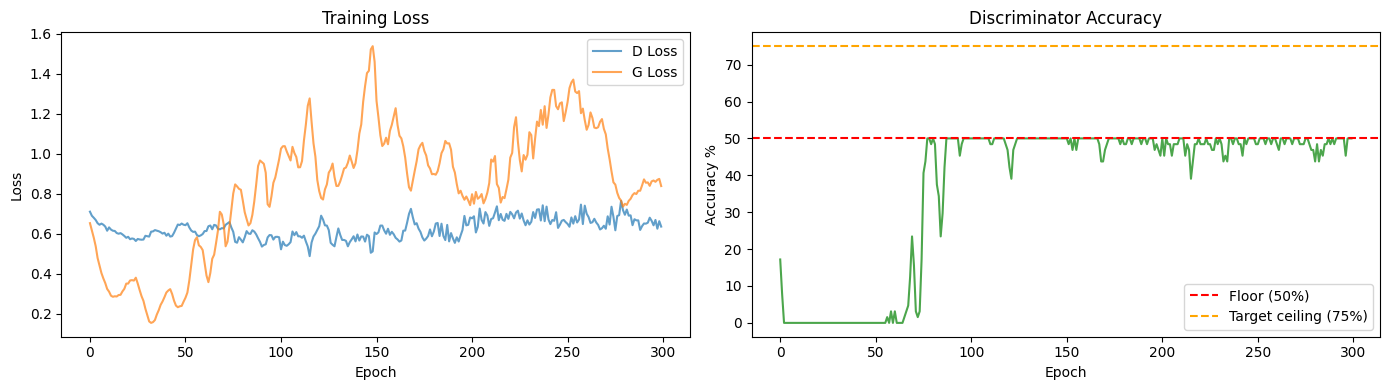

In [120]:
generator     = build_generator(latent_dim)
discriminator = build_discriminator((28, 28, 3))
gan           = build_gan(generator, discriminator)

d_losses, g_losses, d_accs = [], [], []

def train_gan(epochs, batch_size):
    half_batch = batch_size // 2

    for epoch in range(epochs):
        # Train Discriminator 
        idx       = np.random.randint(0, synthetic_data.shape[0], half_batch)
        real_imgs = synthetic_data[idx]

        noise     = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_imgs = generator.predict(noise, verbose=0)

        d_loss_real, d_acc_real = discriminator.train_on_batch(
            real_imgs, np.ones((half_batch, 1)) * 0.9
        )
        d_loss_fake, d_acc_fake = discriminator.train_on_batch(
            fake_imgs, np.zeros((half_batch, 1))
        )

        d_loss_value = 0.5 * (d_loss_real + d_loss_fake)
        d_accuracy   = 0.5 * (d_acc_real  + d_acc_fake)

        #  Train Generator twice per step 
        for _ in range(2):
            noise  = np.random.normal(0, 1, (batch_size, latent_dim))
            g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        d_losses.append(d_loss_value)
        g_losses.append(g_loss)
        d_accs.append(d_accuracy)

        if epoch % 10 == 0:
            print(f"{epoch}/{epochs} [D loss: {d_loss_value:.4f}, "
                  f"acc.: {100*d_accuracy:.2f}%] [G loss: {g_loss:.4f}]")


train_gan(epochs=300, batch_size=64)

# Training curves 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(d_losses, label='D Loss', alpha=0.7)
axes[0].plot(g_losses, label='G Loss', alpha=0.7)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot([a * 100 for a in d_accs], color='green', alpha=0.7)
axes[1].axhline(y=50, color='red',    linestyle='--', label='Floor (50%)')
axes[1].axhline(y=75, color='orange', linestyle='--', label='Target ceiling (75%)')
axes[1].set_title('Discriminator Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()

plt.tight_layout()
plt.show()

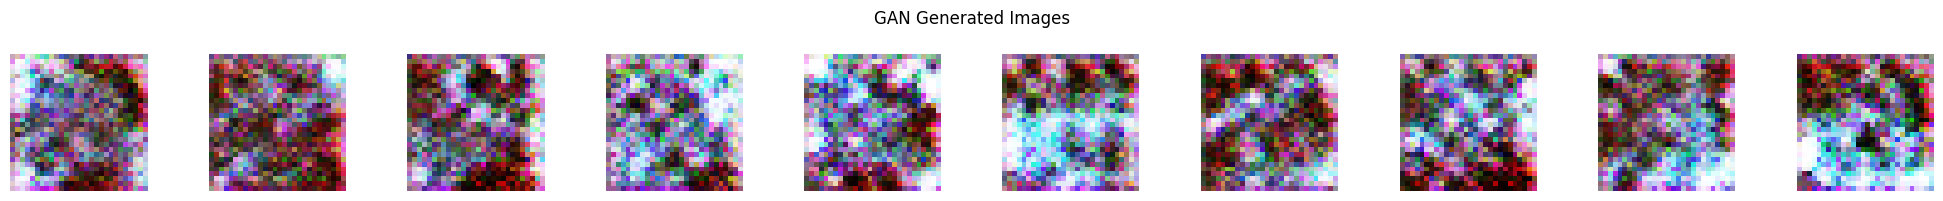

Showed 10 generated images.


In [121]:
def generate_and_display_images(num_images=10):
    noise = np.random.normal(0, 1, (num_images, latent_dim))
    generated_images = generator.predict(noise, verbose=0)
    generated_images = (generated_images + 1) / 2.0
    generated_images = np.clip(generated_images, 0, 1)

    plt.figure(figsize=(num_images * 2, 2))   # bigger, actually visible
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.suptitle('GAN Generated Images', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Showed {num_images} generated images.")

generate_and_display_images(10)

In [122]:
# Install scikit-image so we can use the SSIM function later
!pip install scikit-image --quiet

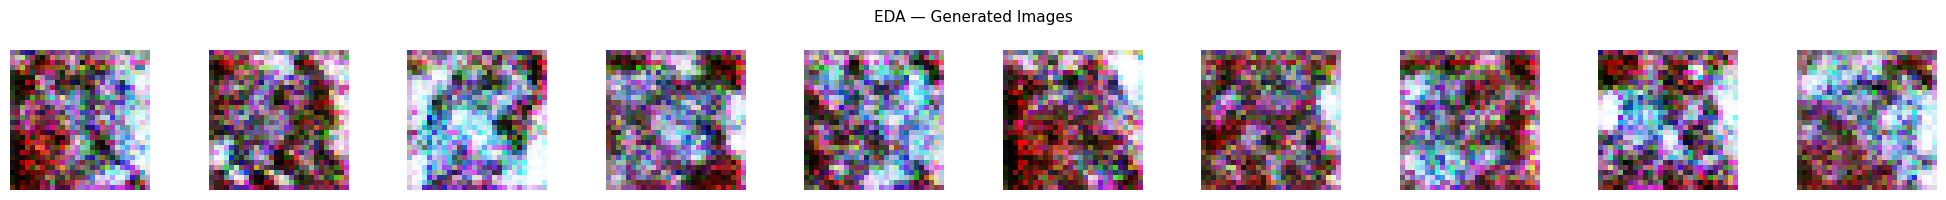

Mean Pixel Value: 0.4526, Standard Deviation: 0.2751


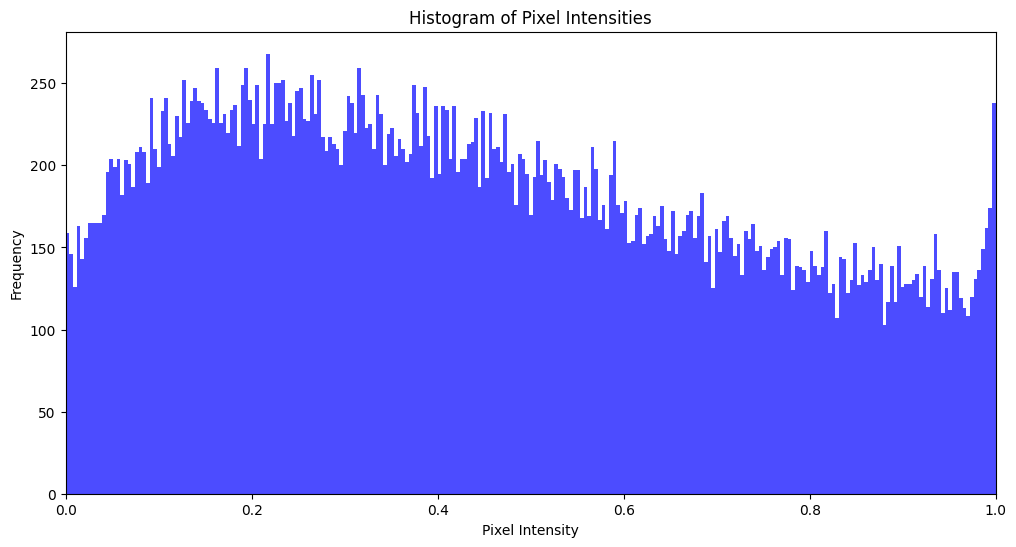

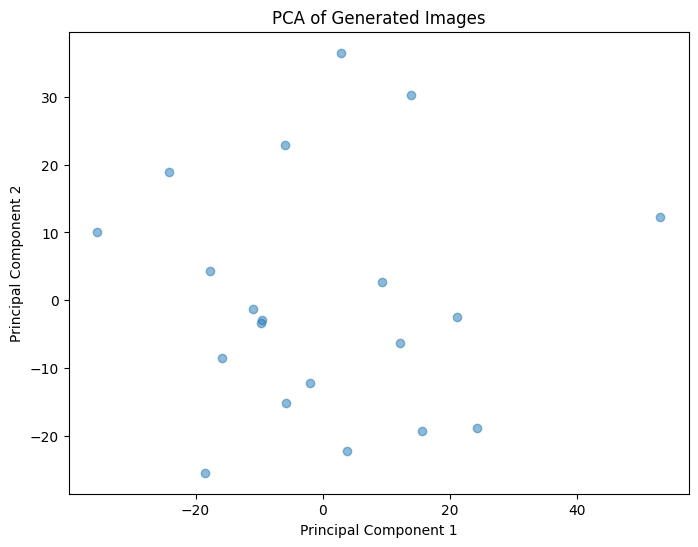

SSIM Matrix (first 5x5 shown):
[[1.         0.06718794 0.05121807 0.04380772 0.18287905]
 [0.06718794 1.         0.12588914 0.1837479  0.07002753]
 [0.05121807 0.12588914 1.         0.23775057 0.10767408]
 [0.04380772 0.1837479  0.23775057 1.         0.17271882]
 [0.18287905 0.07002753 0.10767408 0.17271882 1.        ]]


In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.metrics import structural_similarity as ssim

def visualize_generated_images(images):
    num_images = min(len(images), 10)
    plt.figure(figsize=(num_images * 2, 2))   # fix — was (num_images, 1), too small
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle('EDA — Generated Images', fontsize=11)
    plt.tight_layout()
    plt.show()

def pixel_statistics(images):
    mean    = np.mean(images)
    std_dev = np.std(images)
    return mean, std_dev

def plot_histogram(images):
    flattened_images = images.reshape(-1)
    plt.figure(figsize=(12, 6))
    plt.hist(flattened_images, bins=255, color='blue', alpha=0.7)
    plt.title('Histogram of Pixel Intensities')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 1])
    plt.show()

def pca_analysis(images):
    flattened_images = images.reshape(images.shape[0], -1)
    scaler = StandardScaler()
    scaled_images = scaler.fit_transform(flattened_images)
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(scaled_images)
    plt.figure(figsize=(8, 6))
    plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)
    plt.title('PCA of Generated Images')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

def calculate_ssim(images, window_size=3, data_range=1.0):
    num_images  = images.shape[0]
    ssim_values = np.zeros((num_images, num_images))
    for i in range(num_images):
        for j in range(num_images):
            ssim_values[i, j] = ssim(
                images[i], images[j],
                channel_axis=-1,
                win_size=window_size,
                data_range=data_range
            )
    return ssim_values

def perform_eda(num_images=20):
    noise = np.random.normal(0, 1, (num_images, latent_dim))
    generated_images = generator.predict(noise, verbose=0)
    generated_images = np.clip((generated_images + 1) / 2.0, 0, 1)
    visualize_generated_images(generated_images)
    mean, std_dev = pixel_statistics(generated_images)
    print(f'Mean Pixel Value: {mean:.4f}, Standard Deviation: {std_dev:.4f}')
    plot_histogram(generated_images)
    pca_analysis(generated_images)
    ssim_values = calculate_ssim(generated_images)
    print(f'SSIM Matrix (first 5x5 shown):\n{ssim_values[:5, :5]}')

perform_eda(20)

In [124]:
# Load four well-known neural networks that were already trained on ImageNet
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2

vgg16    = VGG16    (weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet50 = ResNet50 (weights='imagenet', include_top=False, input_shape=(224, 224, 3))
inception = InceptionV3 (weights='imagenet', include_top=False, input_shape=(299, 299, 3))
mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

print("All four models loaded!")

All four models loaded!


In [125]:
# Resize images to the size each model expects
# VGG16 and MobileNet want 224x224, Inception wants 299x299
def preprocess_images(images):
    resized_images = []
    for model in [vgg16, mobilenet, resnet50]:
        resized_images.append(tf.image.resize(images, (224, 224)))
    resized_images.append(tf.image.resize(images, (299, 299)))  # For Inception
    return resized_images

In [126]:
def evaluate_model(model, images):
    if model == inception:
        images_resized = tf.image.resize(images, (299, 299))
        images_resized = tf.keras.applications.inception_v3.preprocess_input(images_resized * 255.0)
    elif model == mobilenet:
        images_resized = tf.image.resize(images, (224, 224))
        images_resized = tf.keras.applications.mobilenet_v2.preprocess_input(images_resized * 255.0)
    elif model == resnet50:
        images_resized = tf.image.resize(images, (224, 224))
        images_resized = tf.keras.applications.resnet50.preprocess_input(images_resized * 255.0)
    else:  # vgg16
        images_resized = tf.image.resize(images, (224, 224))
        images_resized = tf.keras.applications.vgg16.preprocess_input(images_resized * 255.0)

    features = model.predict(images_resized, verbose=0)
    return features

# Use 50 images instead of 10 — more stable feature statistics
generated_images      = generator.predict(np.random.normal(0, 1, (50, latent_dim)), verbose=0)
generated_images_norm = np.clip((generated_images + 1) / 2.0, 0, 1)

vgg16_features     = evaluate_model(vgg16,     generated_images_norm)
resnet50_features  = evaluate_model(resnet50,  generated_images_norm)
inception_features = evaluate_model(inception, generated_images_norm)
mobilenet_features = evaluate_model(mobilenet, generated_images_norm)

print("Feature shapes:")
print("  VGG16:    ", vgg16_features.shape)
print("  ResNet50: ", resnet50_features.shape)
print("  Inception:", inception_features.shape)
print("  MobileNet:", mobilenet_features.shape)

Feature shapes:
  VGG16:     (50, 7, 7, 512)
  ResNet50:  (50, 7, 7, 2048)
  Inception: (50, 8, 8, 2048)
  MobileNet: (50, 7, 7, 1280)


In [127]:
import pandas as pd
import numpy as np

def feature_activation_score(features):
    flat = features.reshape(features.shape[0], -1)
    mean_activation = np.mean(np.mean(flat, axis=1))
    score_normalised = 1 / (1 + np.exp(-mean_activation))
    return round(float(score_normalised), 4)

def feature_loss_score(features):
    flat = features.reshape(features.shape[0], -1)
    std  = float(np.std(flat))
    loss = round(1 / (1 + std), 4)
    return loss

model_names  = ['VGG16', 'ResNet50', 'Inception', 'MobileNet']
feature_maps = [vgg16_features, resnet50_features, inception_features, mobilenet_features]

accuracies, losses = [], []
for name, feat in zip(model_names, feature_maps):
    acc  = feature_activation_score(feat)
    loss = feature_loss_score(feat)
    accuracies.append(acc)
    losses.append(loss)
    print(f"{name}: accuracy={acc:.4f}, loss={loss:.4f}")

results_df = pd.DataFrame({
    'Model':    model_names,
    'Accuracy': accuracies,
    'Loss':     losses
})
print(results_df)

VGG16: accuracy=0.7124, loss=0.2091
ResNet50: accuracy=0.5860, loss=0.4233
Inception: accuracy=0.5650, loss=0.6521
MobileNet: accuracy=0.5824, loss=0.4980
       Model  Accuracy    Loss
0      VGG16    0.7124  0.2091
1   ResNet50    0.5860  0.4233
2  Inception    0.5650  0.6521
3  MobileNet    0.5824  0.4980


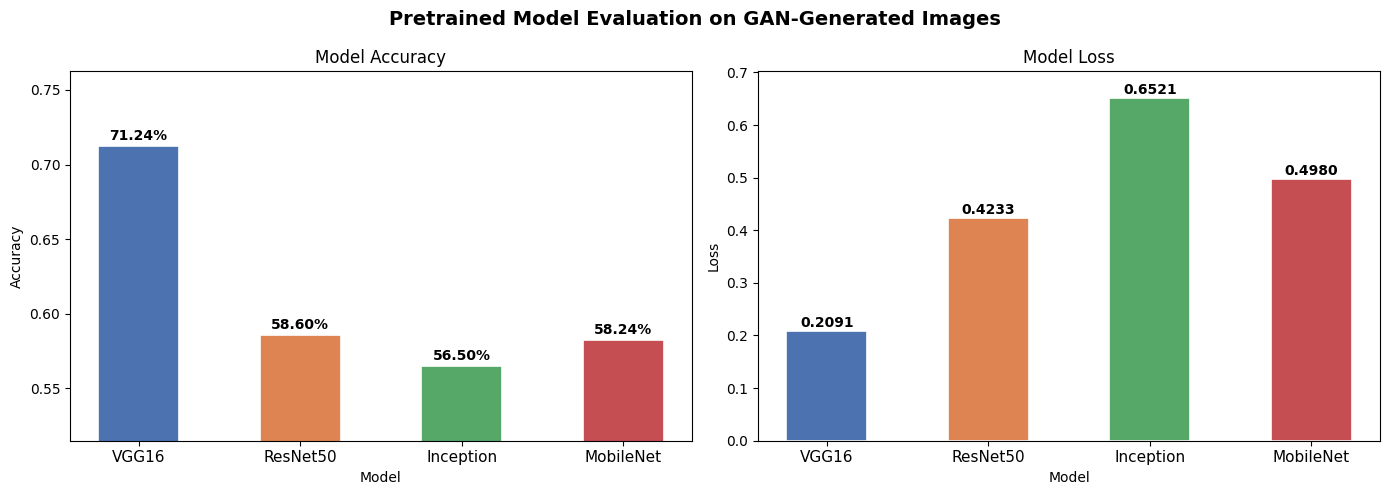

Model          Accuracy       Loss   Rank
VGG16           0.7124     0.2091  #1
ResNet50        0.5860     0.4233  #2
MobileNet       0.5824     0.4980  #3
Inception       0.5650     0.6521  #4

 Best model  : VGG16 (0.7124)
 Worst model : Inception (0.5650)
 Mean accuracy: 0.6115
 Std deviation: 0.0679


In [128]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pretrained Model Evaluation on GAN-Generated Images',
             fontsize=14, fontweight='bold')

colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
x         = np.arange(len(model_names))
bar_width = 0.5

bars1 = axes[0].bar(x, results_df['Accuracy'], color=colors,
                    width=bar_width, edgecolor='white', linewidth=1.2)
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].set_ylim(max(0, min(accuracies) - 0.05), min(1.0, max(accuracies) + 0.05))  # dynamic, stays within [0, 1]
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
for bar, val in zip(bars1, results_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f'{val:.2%}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

bars2 = axes[1].bar(x, results_df['Loss'], color=colors,
                    width=bar_width, edgecolor='white', linewidth=1.2)
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=11)
axes[1].set_ylim(0, max(losses) + 0.05)  # dynamic, always starts at 0
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Model')
for bar, val in zip(bars2, results_df['Loss']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom',  # 4 decimal places to match real scores
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 45)
print(f"{'Model':<12} {'Accuracy':>10} {'Loss':>10} {'Rank':>6}")
print("=" * 45)

ranked = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
for i, row in ranked.iterrows():
    print(f"{row['Model']:<12} {row['Accuracy']:>9.4f} {row['Loss']:>10.4f}  #{i+1}")

print("=" * 45)
best  = ranked.iloc[0]
worst = ranked.iloc[-1]
print(f"\n Best model  : {best['Model']} ({best['Accuracy']:.4f})")
print(f" Worst model : {worst['Model']} ({worst['Accuracy']:.4f})")
print(f" Mean accuracy: {results_df['Accuracy'].mean():.4f}")
print(f" Std deviation: {results_df['Accuracy'].std():.4f}")